In [1]:
import os
import gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from sklearn.manifold import TSNE
from transformers import ViTModel, ViTImageProcessor


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
MODEL_NAME = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

feature_extractor_model = ViTModel.from_pretrained(MODEL_NAME)
feature_extractor_model.eval()

for param in feature_extractor_model.parameters():
    param.requires_grad_(False)
    
feature_extractor_model = feature_extractor_model.to(device)
feature_extractor_model = nn.DataParallel(feature_extractor_model)
hidden_dim = feature_extractor_model.module.config.hidden_size
print(f"hidden_dim = {hidden_dim}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


hidden_dim = 768


In [3]:
mean = processor.image_mean
std = processor.image_std

transform = T.Compose([
    T.Resize((224, 224)), 
    T.ToTensor(), 
    T.Normalize(mean=mean, std=std)
])

train_set = torchvision.datasets.STL10(
    root="./data", 
    split="train", 
    download=True, 
    transform=transform
)

test_set = torchvision.datasets.STL10(
    root="./data", 
    split="test",  
    download=True, 
    transform=transform
)

print(f"Train: {len(train_set)}, Test: {len(test_set)}")
print(f"Classes: {train_set.classes}")

train_loader = DataLoader(train_set, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

100%|██████████| 2.64G/2.64G [09:01<00:00, 4.87MB/s] 


Train: 5000, Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
@torch.no_grad()
def extract_features(loader):
    cls_feats = []
    mean_feats = []
    labels = []
    
    for x, y in loader:
        x = x.to(device)
        last_hidden = feature_extractor_model(pixel_values=x).last_hidden_state
        
        cls_token = last_hidden[:, 0, :]
        patch_tokens_mean = last_hidden[:, 1:, :].mean(dim=1)
        
        cls_feats.append(cls_token.cpu())
        mean_feats.append(patch_tokens_mean.cpu())
        labels.append(y)
        
    return torch.cat(cls_feats), torch.cat(mean_feats), torch.cat(labels)

train_cls, train_mean, train_y = extract_features(train_loader)

test_cls, test_mean, test_y = extract_features(test_loader)

print(f"Train CLS shape: {train_cls.shape}")
print(f"Train Mean shape: {train_mean.shape}")

torch.save({
    "train_cls": train_cls, 
    "train_mean": train_mean, 
    "train_y": train_y,
    "test_cls": test_cls, 
    "test_mean": test_mean, 
    "test_y": test_y
}, "./extracted_features.pt")

del feature_extractor_model
gc.collect()
torch.cuda.empty_cache()

Train CLS shape: torch.Size([5000, 768])
Train Mean shape: torch.Size([5000, 768])


In [5]:
data = torch.load("./extracted_features.pt")

train_cls = data["train_cls"]
train_mean = data["train_mean"]
train_y = data["train_y"]

test_cls = data["test_cls"]
test_mean = data["test_mean"]
test_y = data["test_y"]

n_classes = int(train_y.max().item() + 1)

def train_linear_probe(train_feats, train_labels, test_feats, test_labels, name, epochs=30, lr=1e-2):
    probe = nn.Linear(train_feats.shape[1], n_classes).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=1e-4)
    
    train_feats = train_feats.to(device)
    train_labels = train_labels.to(device)
    test_feats = test_feats.to(device)
    test_labels = test_labels.to(device)
    
    history = {
        "loss": [], 
        "train_acc": [], 
        "test_acc": [], 
        "grad_norm": [], 
        "weight_snapshots": []
    }

    for epoch in range(epochs):
        probe.train()
        optimizer.zero_grad()
        
        logits = probe(train_feats)
        loss = F.cross_entropy(logits, train_labels)
        loss.backward()
        
        grad_norm = probe.weight.grad.norm().item()
        optimizer.step()
        
        with torch.no_grad():
            train_preds = logits.argmax(-1)
            train_acc = (train_preds == train_labels).float().mean().item()
            
            test_preds = probe(test_feats).argmax(-1)
            test_acc = (test_preds == test_labels).float().mean().item()
            
        history["loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["grad_norm"].append(grad_norm)
        
        if epoch % 5 == 0:
            weight_copy = probe.weight.detach().cpu().numpy().copy()
            history["weight_snapshots"].append((epoch, weight_copy))
            print(f"[{name}] Epoch {epoch:2d}, Loss={loss.item():.4f}, Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}, Grad Norm={grad_norm:.4f}")
            
    return probe, history

cls_probe, cls_history = train_linear_probe(train_cls, train_y, test_cls, test_y, "CLS")
mean_probe, mean_history = train_linear_probe(train_mean, train_y, test_mean, test_y, "MeanPool")

[CLS] Epoch  0, Loss=2.3132, Train Acc=0.112, Test Acc=0.979, Grad Norm=4.2645
[CLS] Epoch  5, Loss=0.0182, Train Acc=0.995, Test Acc=0.992, Grad Norm=0.0390
[CLS] Epoch 10, Loss=0.0124, Train Acc=0.996, Test Acc=0.993, Grad Norm=0.0277
[CLS] Epoch 15, Loss=0.0089, Train Acc=0.997, Test Acc=0.994, Grad Norm=0.0206
[CLS] Epoch 20, Loss=0.0061, Train Acc=0.998, Test Acc=0.994, Grad Norm=0.0156
[CLS] Epoch 25, Loss=0.0040, Train Acc=0.999, Test Acc=0.994, Grad Norm=0.0116
[MeanPool] Epoch  0, Loss=2.4099, Train Acc=0.112, Test Acc=0.968, Grad Norm=3.2762
[MeanPool] Epoch  5, Loss=0.0227, Train Acc=0.995, Test Acc=0.995, Grad Norm=0.0390
[MeanPool] Epoch 10, Loss=0.0132, Train Acc=0.996, Test Acc=0.995, Grad Norm=0.0226
[MeanPool] Epoch 15, Loss=0.0102, Train Acc=0.997, Test Acc=0.995, Grad Norm=0.0178
[MeanPool] Epoch 20, Loss=0.0075, Train Acc=0.998, Test Acc=0.995, Grad Norm=0.0152
[MeanPool] Epoch 25, Loss=0.0050, Train Acc=0.998, Test Acc=0.995, Grad Norm=0.0119


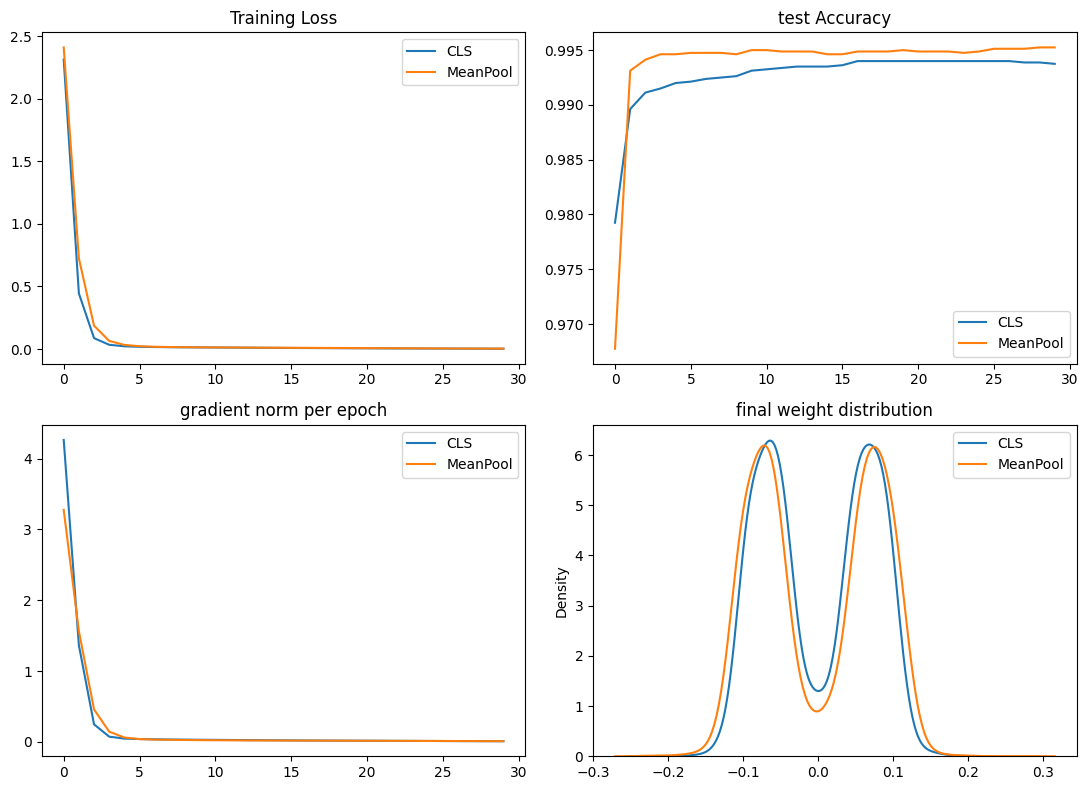

Final Test Accuracy — CLS: 0.994 | MeanPool: 0.995


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(cls_history["loss"], label="CLS")
axes[0, 0].plot(mean_history["loss"], label="MeanPool")
axes[0, 0].set_title("Training Loss")
axes[0, 0].legend()

axes[0, 1].plot(cls_history["test_acc"], label="CLS")
axes[0, 1].plot(mean_history["test_acc"], label="MeanPool")
axes[0, 1].set_title("test Accuracy")
axes[0, 1].legend()

axes[1, 0].plot(cls_history["grad_norm"], label="CLS")
axes[1, 0].plot(mean_history["grad_norm"], label="MeanPool")
axes[1, 0].set_title("gradient norm per epoch")
axes[1, 0].legend()

sns.kdeplot(cls_history["weight_snapshots"][-1][1].flatten(), ax=axes[1, 1], label="CLS")
sns.kdeplot(mean_history["weight_snapshots"][-1][1].flatten(), ax=axes[1, 1], label="MeanPool")
axes[1, 1].set_title("final weight distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Final Test Accuracy — CLS: {cls_history['test_acc'][-1]:.3f} | MeanPool: {mean_history['test_acc'][-1]:.3f}")

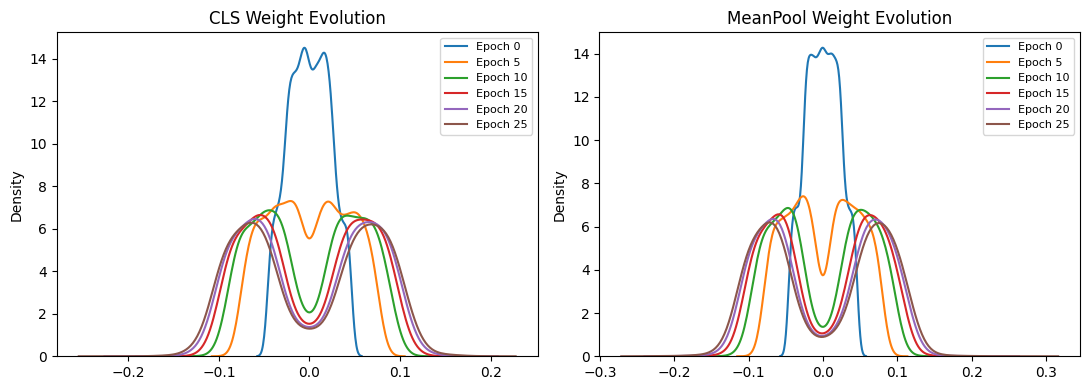

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for epoch, weights in cls_history["weight_snapshots"]:
    sns.kdeplot(weights.flatten(), ax=axes[0], label=f"Epoch {epoch}")
axes[0].set_title("CLS Weight Evolution")
axes[0].legend(fontsize=8)

for epoch, weights in mean_history["weight_snapshots"]:
    sns.kdeplot(weights.flatten(), ax=axes[1], label=f"Epoch {epoch}")
axes[1].set_title("MeanPool Weight Evolution")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()